In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,r2_score,confusion_matrix

In [2]:
df=pd.read_csv('Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [5]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


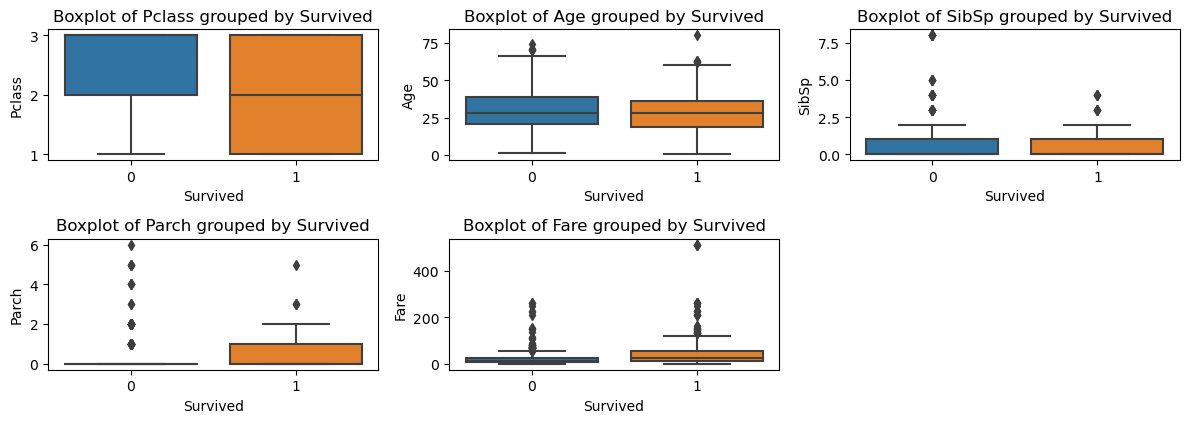

In [6]:
numerical_columns = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
plt.figure(figsize=(12, 6))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Survived', y=column, data=df)
    plt.title(f'Boxplot of {column} grouped by Survived')

plt.tight_layout()
plt.show()

In [7]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [8]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [9]:
df.dropna(subset=['Embarked'], inplace=True)
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [10]:
df['Age']=df['Age'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    int32  
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(1), int32(1), int64(4), object(2)
memory usage: 59.0+ KB


In [11]:
print('Skewness value of Age:',df['Age'].skew())
print('Skewness value of Fare:',df['Fare'].skew())
print('Skewness value of Parch:',df['Parch'].skew())
print('Skewness value of SibSp:',df['SibSp'].skew())

Skewness value of Age: 0.4569465528010798
Skewness value of Fare: 4.801440211044194
Skewness value of Parch: 2.74516012611158
Skewness value of SibSp: 3.6910576308362284


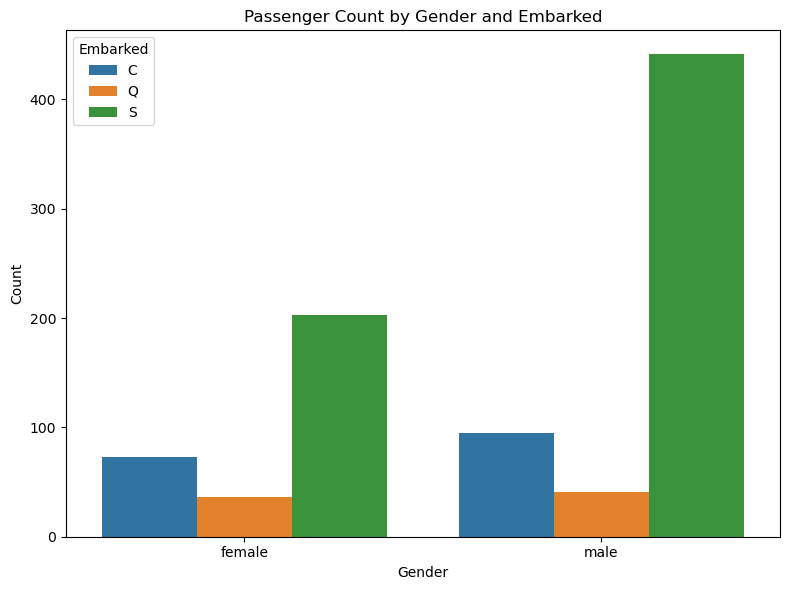

In [12]:
embark = df.groupby(['Sex', 'Embarked']).size().reset_index(name='Count')
plt.figure(figsize=(8, 6))
sns.barplot(x='Sex', y='Count', hue='Embarked', data=embark)

plt.title('Passenger Count by Gender and Embarked')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Embarked', loc='upper left')
plt.tight_layout()
plt.show()

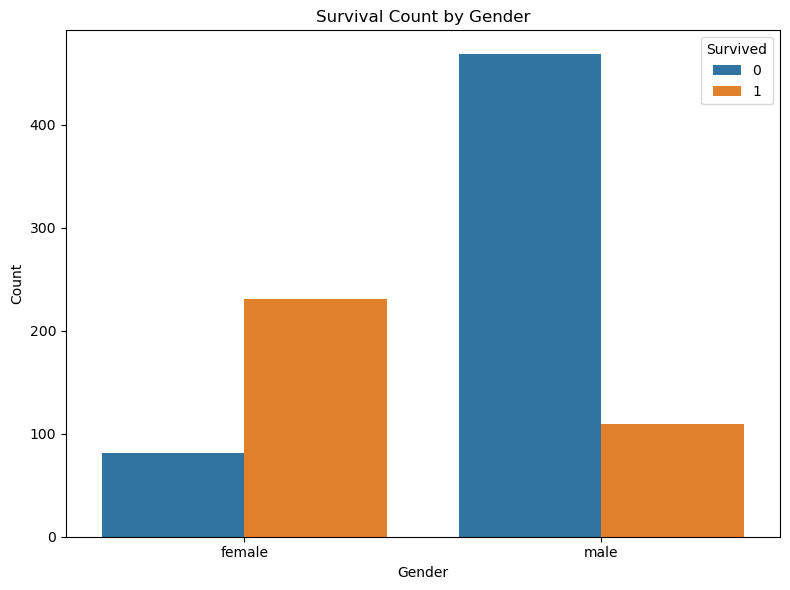

In [13]:
gender = df.groupby(['Sex', 'Survived']).size().reset_index(name='Count').fillna(0)
plt.figure(figsize=(8, 6))
sns.barplot(x='Sex', y='Count', hue='Survived', data=gender)
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Survived', loc='upper right')
plt.tight_layout()
plt.show()

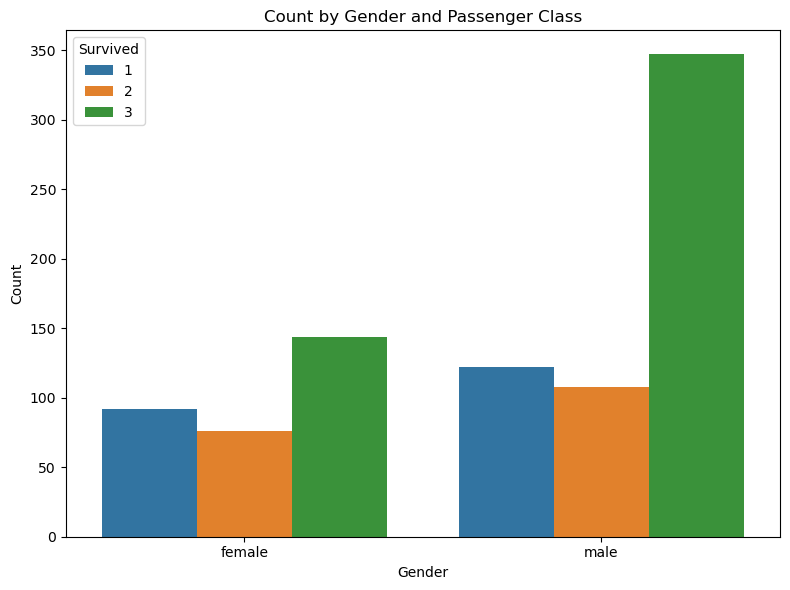

In [14]:
p_class = df.groupby(['Sex', 'Pclass']).size().reset_index(name='Count').fillna(0)
plt.figure(figsize=(8, 6))
sns.barplot(x='Sex', y='Count', hue='Pclass', data=p_class)
plt.title('Count by Gender and Passenger Class')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Survived', loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
df["Sex"]=df["Sex"].replace({"male":1,"female":0})
df["Embarked"]=df["Embarked"].replace({"S":0,"C":1,"Q":2})
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22,1,0,7.2500,0
1,1,1,0,38,1,0,71.2833,1
2,1,3,0,26,0,0,7.9250,0
3,1,1,0,35,1,0,53.1000,0
4,0,3,1,35,0,0,8.0500,0
...,...,...,...,...,...,...,...,...
886,0,2,1,27,0,0,13.0000,0
887,1,1,0,19,0,0,30.0000,0
888,0,3,0,29,1,2,23.4500,0
889,1,1,1,26,0,0,30.0000,1


<Axes: >

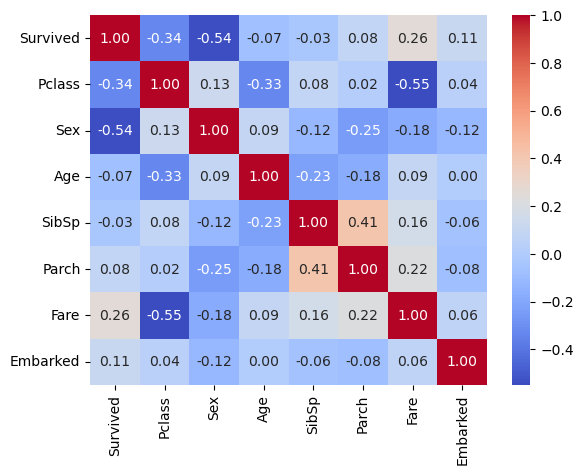

In [16]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [17]:
X = df.drop(columns=["Survived",'SibSp','Parch'])
y = df["Survived"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.4,random_state=42)

In [43]:
X

,Pclass,Sex,Age,Fare,Embarked
0,3,1,22,7.2500,0
1,1,0,38,71.2833,1
2,3,0,26,7.9250,0
3,1,0,35,53.1000,0
4,3,1,35,8.0500,0
...,...,...,...,...,...
886,2,1,27,13.0000,0
887,1,0,19,30.0000,0
888,3,0,29,23.4500,0
889,1,1,26,30.0000,1


In [18]:
scaler = RobustScaler()
X_train[['Age', 'Fare']] = scaler.fit_transform(X_train[['Age', 'Fare']])
X_test[['Age', 'Fare']] = scaler.transform(X_test[['Age', 'Fare']])

In [41]:
X_train

,Pclass,Sex,Age,Fare,Embarked
569,3,1,0.230769,-0.291981,0
786,3,0,-0.846154,-0.307837,0
75,3,1,-0.307692,-0.301015,0
114,3,0,-0.923077,0.000181,1
597,3,1,1.538462,-0.639448,0
...,...,...,...,...,...
107,3,1,0.000000,-0.295485,0
271,3,1,-0.307692,-0.639448,0
862,1,0,1.461538,0.507649,0
436,3,0,-0.615385,0.881288,0


In [29]:
model_rf=RandomForestRegressor(n_estimators=100)
model_rf.fit(X_train,y_train)
y_pred_rf = model_rf.predict(X_test)

In [20]:
mse_rf = mean_squared_error(y_test,y_pred_rf)
r2_rf = r2_score(y_test,y_pred_rf)
print('Mean Squared Error:',mse_rf.round(2))
print('R2_Score:',r2_rf.round(2))

Mean Squared Error: 0.16
R2_Score: 0.34


In [21]:
model_lr=LinearRegression()
model_lr.fit(X_train,y_train)
y_pred_lr = model_lr.predict(X_test)

In [22]:
mse_lr = mean_squared_error(y_test,y_pred_lr)
r2_lr=r2_score(y_test,y_pred_lr)
print('Mean Squared Error:',mse_lr.round(2))
print('R2_Score:',r2_lr.round(2))

Mean Squared Error: 0.15
R2_Score: 0.38


In [23]:
model_svr=SVR(kernel='linear',epsilon=0.1,gamma='scale')
model_svr.fit(X_train,y_train)
y_pred_svr = model_svr.predict(X_test)

In [24]:
mse_svr = mean_squared_error(y_test,y_pred_svr)
r2_svr=r2_score(y_test,y_pred_svr)
print('Mean Squared Error:',mse_svr.round(2))
print('R2_Score:',r2_svr.round(2))

Mean Squared Error: 0.18
R2_Score: 0.24


Text(0.5, 1.0, 'Confusion Matrix')

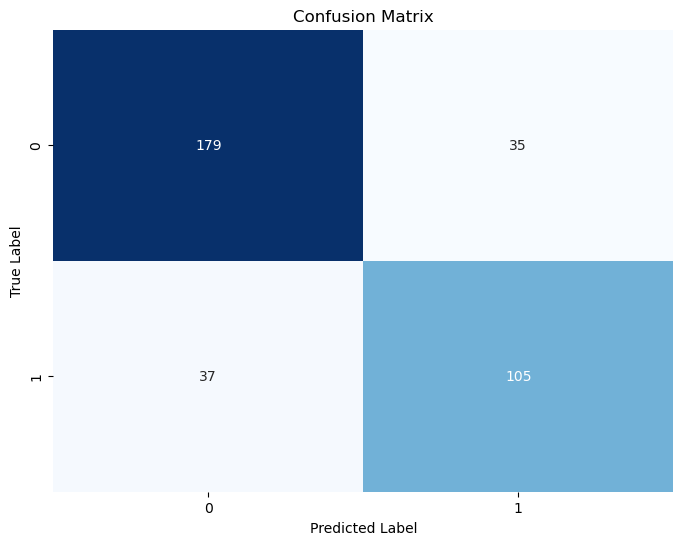

In [58]:
threshold = 0.5
y_pred_binary = (y_pred_rf > threshold).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

In [25]:
X_test.head()

,Pclass,Sex,Age,Fare,Embarked
281,3,1,-0.076923,-0.291981,0
435,1,0,-1.153846,4.669300,0
39,3,0,-1.153846,-0.142120,1
418,2,1,0.076923,-0.064333,0
585,1,0,-0.846154,2.884234,0


In [26]:
y_test.head()

281    0
435    1
39     1
418    0
585    1
Name: Survived, dtype: int64

In [46]:
new_data = {
    'Pclass':[2]
    ,'Sex':[1]
    ,'Age':[31]
    ,'Fare':[12.29]
    ,'Embarked':[3]
}
new_input_df = pd.DataFrame(new_data)
predicted_new_survival = model_rf.predict(new_input_df)
new_input_df['Predicted_survival'] = predicted_new_survival
print(new_input_df)

   Pclass  Sex  Age   Fare  Embarked  Predicted_survival
0       2    1   31  12.29         3                0.23
